# Lesson 23: MovieLens recommendation system demonstration



This notebook uses the MovieLens 100K dataset to demonstrate core recommendation system techniques.



Dataset source: [MovieLens 100K](https://grouplens.org/datasets/movielens/100k/)



1. **Notebook set up**



2. **Collaborative filtering**

    - Memory-based: item-item cosine similarity

    - Model-based: matrix factorization with SVD



3. **Content-based filtering**: genre cosine similarity



4. **Hybrid filtering**: weighted combination of both approaches



5. **Evaluation**: GetTopN and hit rate



6. **Export for web app deployment**



7. **Challenges**: cold start, implicit vs explicit feedback



8. **More advanced techniques**



## 1. Notebook set up



### Imports

In [1]:
import io
import os
import pickle
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

### Dataset

The [MovieLens 100K dataset](https://grouplens.org/datasets/movielens/100k/) contains 100,000 ratings given by 943 users to 1,682 movies on a 1-5 star scale. It was collected by the GroupLens Research Project at the University of Minnesota and is a standard benchmark for recommendation system research.

The dataset has two tables:
- **Ratings**: one row per (user, movie) pair with a 1-5 star rating.
- **Movies**: one row per movie with title and 19 binary genre flags.

In [2]:
# Use Python's requests library to get zip archive of data
url = 'https://files.grouplens.org/datasets/movielens/ml-100k.zip'
response = requests.get(url)

# Create read-only zipfile object in memory from response content
z = zipfile.ZipFile(io.BytesIO(response.content))

# Load ratings
ratings = pd.read_csv(
    z.open('ml-100k/u.data'),
    sep='\t',
    names=['user_id', 'movie_id', 'rating', 'timestamp']
).drop(columns=['timestamp'])

# Load genre/name list
genre_names = pd.read_csv(
    z.open('ml-100k/u.genre'),
    sep='|',
    names=['genre', 'genre_id'],
    encoding='latin-1'
)['genre'].tolist()

In [3]:
# Example ratings data
ratings.head()

,user_id,movie_id,rating
0,196,242,3
1,186,302,3
2,22,377,1
3,244,51,2
4,166,346,1


In [4]:
# First 10 genre names
genre_names[:10]

['unknown',
 'Action',
 'Adventure',
 'Animation',
 "Children's",
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Fantasy']

In [5]:
# Load movie data
movie_cols = ['movie_id', 'title', 'release_date', 'video_release', 'imdb_url'] + genre_names

movies = pd.read_csv(
    z.open('ml-100k/u.item'),
    sep='|',
    names=movie_cols,
    encoding='latin-1'
)[['movie_id', 'title'] + genre_names]

print(f'Ratings: {len(ratings):,} rows')
print(f'Movies:  {len(movies):,} rows')
print(f'Users:   {ratings["user_id"].nunique():,}')
print(f'Rating scale: {ratings["rating"].min()}-{ratings["rating"].max()}')

Ratings: 100,000 rows
Movies:  1,682 rows
Users:   943
Rating scale: 1-5


In [6]:
ratings.head()

,user_id,movie_id,rating
0,196,242,3
1,186,302,3
2,22,377,1
3,244,51,2
4,166,346,1


In [7]:
movies.head().T

,0,1,2,3,4
movie_id,1,2,3,4,5
title,Toy Story (1995),GoldenEye (1995),Four Rooms (1995),Get Shorty (1995),Copycat (1995)
unknown,0,0,0,0,0
Action,0,1,0,1,0
Adventure,0,1,0,0,0
Animation,1,0,0,0,0
Children's,1,0,0,0,0
Comedy,1,0,0,1,0
Crime,0,0,0,0,1
Documentary,0,0,0,0,0


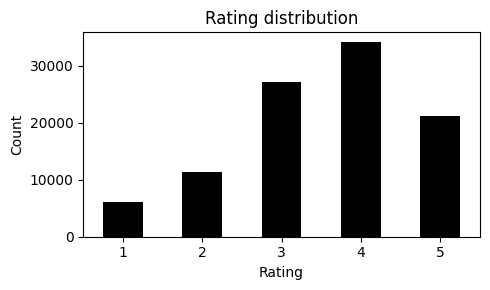

In [8]:
ratings['rating'].value_counts().sort_index().plot(kind='bar', color='black', figsize=(5, 3))
plt.title('Rating distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Collaborative filtering



Collaborative filtering recommends items based on the collective behaviour of all users. It does not use item content; it relies entirely on the pattern of who rated what and how highly.



### 2.1. Memory-based collaborative filtering



Memory-based collaborative filtering compares items directly using a similarity metric computed from the rating matrix. No model is trained; all computation happens at query time from the stored similarity matrix.



Similarity between two items is computed with cosine similarity over their rating vectors across all users:



$$\text{sim}(i, j) = \frac{r_i \cdot r_j}{\|r_i\| \|r_j\|}$$



A value of 1 means identical rating patterns; 0 means no shared users.

In [9]:
# Build user-item matrix (rows = users, columns = movies)
user_item_matrix = ratings.pivot_table(
    index='user_id',
    columns='movie_id',
    values='rating'
)

# Fill unrated entries with 0 for cosine similarity
user_item_filled = user_item_matrix.fillna(0)

print(f'User-item matrix shape: {user_item_filled.shape}')
user_item_filled.head()

User-item matrix shape: (943, 1682)


movie_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
# Transpose so items are rows, then compute pairwise cosine similarity
item_similarity = cosine_similarity(user_item_filled.T)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=user_item_matrix.columns,
    columns=user_item_matrix.columns
)

print(f'Item similarity matrix shape: {item_similarity_df.shape}')
item_similarity_df.head()

Item similarity matrix shape: (1682, 1682)


movie_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
movie_id,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.402382,0.330245,0.454938,0.286714,0.116344,0.620979,0.481114,0.496288,0.273935,...,0.035387,0.0,0.000000,0.000000,0.035387,0.0,0.0,0.0,0.047183,0.047183
2,0.402382,1.000000,0.273069,0.502571,0.318836,0.083563,0.383403,0.337002,0.255252,0.171082,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.078299,0.078299
3,0.330245,0.273069,1.000000,0.324866,0.212957,0.106722,0.372921,0.200794,0.273669,0.158104,...,0.000000,0.0,0.000000,0.000000,0.032292,0.0,0.0,0.0,0.000000,0.096875
4,0.454938,0.502571,0.324866,1.000000,0.334239,0.090308,0.489283,0.490236,0.419044,0.252561,...,0.000000,0.0,0.094022,0.094022,0.037609,0.0,0.0,0.0,0.056413,0.075218
5,0.286714,0.318836,0.212957,0.334239,1.000000,0.037299,0.334769,0.259161,0.272448,0.055453,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.094211


In [ ]:
def get_title(movie_id):
    '''Return movie title for a given ID.'''

    result = movies.loc[movies['movie_id'] == movie_id, 'title']
    return result.values[0] if len(result) > 0 else f'Unknown ({movie_id})'


def memory_recommendations(movie_id, n=5):
    '''Return the top n movies most similar to movie_id by item-item cosine similarity.'''

    scores = item_similarity_df[movie_id].sort_values(ascending=False).iloc[1:n + 1]

    return pd.DataFrame({
        'title': [get_title(mid) for mid in scores.index],
        'similarity': scores.values.round(4)
    }, index=scores.index)

# Toy Story (movie_id = 1)
print(f'Memory-based recommendations for "{get_title(1)}":')
memory_recommendations(1)

Memory-based recommendations for "Toy Story (1995)":


,title,similarity
movie_id,,
50,Star Wars (1977),0.7346
181,Return of the Jedi (1983),0.6999
121,Independence Day (ID4) (1996),0.6898
117,"Rock, The (1996)",0.6646
405,Mission: Impossible (1996),0.6413


### 2.2. Model-based collaborative filtering



Model-based collaborative filtering uses matrix factorization to learn a compact latent representation of users and items. Truncated SVD decomposes the user-item matrix into latent factors that capture hidden patterns (e.g. genre preferences), then reconstructs predicted ratings for user-movie pairs the user has not yet rated.



$$X \approx U_k \Sigma_k V_k^T$$



Where $U_k$ contains user latent factors, $\Sigma_k$ scales each component, and $V_k^T$ contains item latent factors. The product fills in predicted ratings across the full matrix.

In [14]:
svd = TruncatedSVD(n_components=50, random_state=315)
user_factors = svd.fit_transform(user_item_filled)

# Reconstruct the full ratings matrix from latent factors
predicted_ratings = np.dot(user_factors, svd.components_)

predicted_ratings_df = pd.DataFrame(
    predicted_ratings,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)

print(f'Predicted ratings matrix shape: {predicted_ratings_df.shape}')
print(f'Variance explained by 50 components: {svd.explained_variance_ratio_.sum():.1%}')
predicted_ratings_df.head()

Predicted ratings matrix shape: (943, 1682)
Variance explained by 50 components: 52.4%


movie_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,6.506234,2.586196,1.574600,2.584513,1.420102,1.531108,4.415929,1.338277,1.078905,2.846275,...,0.051324,-0.041984,-0.051310,-0.034206,0.015757,-0.002322,-0.006965,-0.004643,0.035249,0.054830
2,2.399742,0.462202,0.048899,0.339038,0.214552,0.517275,0.015426,-0.363213,2.104612,0.610305,...,0.022276,-0.033809,-0.024924,-0.016616,-0.004899,0.001088,0.003263,0.002175,0.006681,-0.016521
3,0.171814,-0.191129,-0.131494,-0.150385,0.093206,-0.066813,0.016007,0.677893,0.168539,0.212851,...,-0.016763,-0.018399,0.069130,0.046087,-0.003769,0.015563,0.046689,0.031126,0.004082,-0.000249
4,0.391900,-0.294468,0.036593,-0.000504,0.024111,0.082817,0.236818,-0.216544,0.083964,-0.117373,...,0.000497,-0.022420,-0.014679,-0.009786,0.007321,0.005697,0.017090,0.011393,-0.005285,-0.016400
5,4.136541,1.888161,0.154475,1.007556,0.555010,0.292942,1.677359,0.344610,0.468623,0.242909,...,0.007956,-0.082470,0.009044,0.006029,-0.057786,-0.002230,-0.006691,-0.004461,-0.046427,-0.001119


In [15]:
def model_recommendations(user_id, n=5):
    '''Return the top n unrated movies by predicted rating for a given user.'''

    user_actual = user_item_matrix.loc[user_id]
    unrated = user_actual[user_actual.isna()].index
    predicted = predicted_ratings_df.loc[user_id, unrated].sort_values(ascending=False).iloc[:n]

    return pd.DataFrame({
        'title': [get_title(mid) for mid in predicted.index],
        'predicted_rating': predicted.values.round(3)
    }, index=predicted.index)


user_id = user_item_matrix.index[0]
print(f'Model-based recommendations for user {user_id}:')
model_recommendations(user_id)

Model-based recommendations for user 1:


,title,predicted_rating
movie_id,,
276,Leaving Las Vegas (1995),3.310
403,Batman (1989),3.069
423,E.T. the Extra-Terrestrial (1982),2.938
732,Dave (1993),2.739
509,My Left Foot (1989),2.711


## 3. Content-based filtering



Content-based filtering recommends items similar to ones a user has already liked, using item attributes rather than other users' behaviour. Here each movie is represented as a binary genre vector with one entry per genre flag in the MovieLens metadata.



Similarity between two movies is cosine similarity over their genre vectors:



$$\text{sim}(i, j) = \frac{g_i \cdot g_j}{\|g_i\| \|g_j\|}$$



A score of 1 means both movies share exactly the same genres; 0 means they share no genres.

In [16]:
# Build genre feature matrix (rows = movies, columns = genres)
genre_matrix = movies[genre_names].values

genre_similarity = cosine_similarity(genre_matrix)

genre_similarity_df = pd.DataFrame(
    genre_similarity,
    index=movies['movie_id'],
    columns=movies['movie_id']
)

print(f'Genre similarity matrix shape: {genre_similarity_df.shape}')

Genre similarity matrix shape: (1682, 1682)


In [17]:
genre_similarity_df.head()

movie_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
movie_id,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.000000,0.00000,0.333333,0.000000,0.00000,0.000000,0.666667,0.00000,0.000000,...,0.000000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000000,0.000000,0.57735,0.00000
2,0.000000,1.000000,0.57735,0.333333,0.333333,0.00000,0.000000,0.000000,0.00000,0.000000,...,0.816497,0.00000,0.00000,0.00000,0.00000,0.00000,0.408248,0.000000,0.00000,0.00000
3,0.000000,0.577350,1.00000,0.000000,0.577350,0.00000,0.000000,0.000000,0.00000,0.000000,...,0.707107,0.00000,0.00000,0.00000,0.00000,0.00000,0.707107,0.000000,0.00000,0.00000
4,0.333333,0.333333,0.00000,1.000000,0.333333,0.57735,0.408248,0.666667,0.57735,0.408248,...,0.408248,0.57735,0.57735,0.57735,0.57735,0.57735,0.000000,0.408248,0.57735,0.57735
5,0.000000,0.333333,0.57735,0.333333,1.000000,0.57735,0.408248,0.333333,0.57735,0.408248,...,0.408248,0.57735,0.57735,0.57735,0.57735,0.57735,0.408248,0.408248,0.00000,0.57735


In [18]:
def content_recommendations(movie_id, n=5):
    '''Return the top n movies with the most similar genre profile.'''

    target_row = movies.loc[movies['movie_id'] == movie_id, genre_names].values[0]
    target_genres = ', '.join([g for g, v in zip(genre_names, target_row) if v == 1])

    scores = genre_similarity_df[movie_id].sort_values(ascending=False).iloc[1:n + 1]

    results = []

    for mid, score in scores.items():
        row = movies.loc[movies['movie_id'] == mid, genre_names].values[0]
        genres = ', '.join([g for g, v in zip(genre_names, row) if v == 1])
        results.append({'title': get_title(mid), 'genres': genres, 'similarity': round(score, 4)})

    print(f'Content-based recommendations for "{get_title(movie_id)}"')
    print(f'Target genres: {target_genres}')

    return pd.DataFrame(results)


content_recommendations(1)

Content-based recommendations for "Toy Story (1995)"
Target genres: Animation, Children's, Comedy


,title,genres,similarity
0,Aladdin and the King of Thieves (1996),"Animation, Children's, Comedy",1.0000
1,Aladdin (1992),"Animation, Children's, Comedy, Musical",0.8660
2,"Goofy Movie, A (1995)","Animation, Children's, Comedy, Romance",0.8660
3,Jungle2Jungle (1997),"Children's, Comedy",0.8165
4,Angels in the Outfield (1994),"Children's, Comedy",0.8165


## 4. Hybrid filtering



Hybrid filtering combines collaborative and content-based scores into a single ranking. Because the two score distributions differ, both are normalised to $[0, 1]$ before combining. The parameter $\alpha$ controls the balance between the two approaches:



$$s_{\text{hybrid}} = \alpha \cdot \hat{s}_{\text{collab}} + (1 - \alpha) \cdot \hat{s}_{\text{content}}$$



Setting $\alpha = 1$ reduces to pure collaborative filtering; $\alpha = 0$ reduces to pure content-based filtering.

In [ ]:
def normalize(series):
    '''Scale a series to [0, 1].'''

    lo, hi = series.min(), series.max()

    return (series - lo) / (hi - lo) if hi > lo else series * 0


def hybrid_recommendations(movie_id, n=5, alpha=0.5):
    '''Return the top n movies by weighted combination of collab and content scores.'''

    collab = item_similarity_df[movie_id] if movie_id in item_similarity_df.columns else pd.Series(dtype=float)
    content = genre_similarity_df[movie_id]

    common = collab.index.intersection(content.index)
    common = common[common != movie_id]

    hybrid = alpha * normalize(collab[common]) + (1 - alpha) * normalize(content[common])
    top = hybrid.sort_values(ascending=False).iloc[:n]

    results = [{'title': get_title(mid), 'hybrid_score': round(score, 4)} for mid, score in top.items()]
    print(f'Hybrid recommendations for "{get_title(movie_id)}" (alpha={alpha}):')

    return pd.DataFrame(results)

hybrid_recommendations(1)

Hybrid recommendations for "Toy Story (1995)" (alpha=0.5):


,title,hybrid_score
0,Aladdin (1992),0.8291
1,Willy Wonka and the Chocolate Factory (1971),0.7677
2,Beauty and the Beast (1991),0.7106
3,"Lion King, The (1994)",0.7096
4,Beavis and Butt-head Do America (1996),0.7015


## 5. Evaluation



Evaluating a recommendation system requires simulating the real-world scenario where some ratings are known and others are withheld. A **leave-one-out** strategy holds out one randomly chosen rating per user as the test item and trains the model on the remaining ratings.



One important detail: only **positively-rated items** (rating ≥ 4) should be held out. If we hold out a movie the user rated 1 or 2 stars, finding it in the top-10 is not a success; the model would be recommending something the user disliked. Users with no positive ratings have no test item and are excluded from the evaluation.



**Note on production practice:** two common refinements are used in rigorous benchmarks. First, a **time-based split** holds out each user's *most recent* positive interaction rather than a random one, preventing the model from using future data to predict the past. Second, many papers use a **sampled ranking** protocol (the model ranks the 1 test item against 100 randomly sampled unrated items) instead of ranking across all items, which is much cheaper to compute at scale.



### 5.1. Train/test split

In [ ]:
# Only hold out positively-rated items; a hit on a disliked movie is not meaningful
positive_ratings = ratings[ratings['rating'] >= 4]
held_out = positive_ratings.groupby('user_id').sample(n=1, random_state=315)
test_ratings = held_out.reset_index(drop=True)
train_ratings = ratings.drop(index=held_out.index)

print(f'Train ratings: {len(train_ratings):,}')
print(f'Test ratings:  {len(test_ratings):,}  (one positively-rated item per user)')

In [ ]:
# Retrain SVD on training data only
train_matrix = train_ratings.pivot_table(
    index='user_id', columns='movie_id', values='rating'
).fillna(0)

svd_eval = TruncatedSVD(n_components=50, random_state=315)

train_preds = pd.DataFrame(
    np.dot(svd_eval.fit_transform(train_matrix), svd_eval.components_),
    index=train_matrix.index,
    columns=train_matrix.columns
)

print(f'Training predictions shape: {train_preds.shape}')

### 5.2. GetTopN



`GetTopN` generates the ranked recommendation list for each user: it identifies items the user has not rated in the training data, ranks them by predicted rating, and returns the top-N. It is the bridge between raw model predictions and a usable list of recommendations.

In [ ]:
def get_top_n(predicted_df, train_matrix, n=10):
    '''For each user, return the top-N unrated movie IDs ranked by predicted rating.'''

    top_n = {}

    for user_id in predicted_df.index:
        rated = train_matrix.loc[user_id][train_matrix.loc[user_id] > 0].index
        preds = predicted_df.loc[user_id].drop(index=rated, errors='ignore')
        top_n[user_id] = preds.sort_values(ascending=False).iloc[:n].index.tolist()

    return top_n

In [ ]:
top_n_recs = get_top_n(train_preds, train_matrix, n=10)

example_user = list(top_n_recs.keys())[0]
print(f'Generated top-10 lists for {len(top_n_recs)} users')
print(f'\nExample: top-10 for user {example_user}:')

for title in [get_title(mid) for mid in top_n_recs[example_user]]:
    print(f'  {title}')

### 5.3. Hit rate



Hit rate measures how often the model's top-N list contains the held-out test item:



$$\text{Hit Rate@}N = \frac{|\{u : \text{test item} \in \text{top-}N(u)\}|}{|U|}$$



Where $U$ is the set of users with a positive test item and $\text{top-}N(u)$ is the set of recommended items for user $u$. A hit rate of 0.05 at $N = 10$ means 5% of those users had their held-out movie appear in their top-10 list.



Because we only held out positively-rated items, a hit genuinely means the model surfaced something the user liked. Without this filter, the metric would credit the model for recommending movies the user had already rated poorly.



Hit rate rewards the model for placing the test item anywhere in the top-N. It is often paired with NDCG (normalised discounted cumulative gain), which additionally rewards higher placements within the list.

In [ ]:
def hit_rate(top_n_dict, test_df):
    '''Fraction of users whose held-out test movie appears in their top-N list.'''

    eligible = test_df[test_df['user_id'].isin(top_n_dict)]
    hits = eligible.apply(lambda row: row['movie_id'] in top_n_dict[row['user_id']], axis=1).sum()

    return hits / len(eligible) if len(eligible) > 0 else 0.0


hr = hit_rate(top_n_recs, test_ratings)
print(f'Hit rate @ 10: {hr:.3f}')
print(f'About 1 in {1/hr:.0f} users had their held-out movie in the top-10 list')

## 6. Export for web app deployment



The three pre-computed similarity matrices and supporting data are saved to a single pickle file. A web app can load this file at startup and serve recommendations without re-running any computation. The file contains everything needed to:



- Look up a movie by title and return memory-based recommendations.

- Return model-based (SVD) recommendations for a given user.

- Return content-based recommendations by genre profile.

- Return hybrid recommendations with a configurable `alpha`.

In [ ]:
export = {
    'item_similarity_df': item_similarity_df,
    'genre_similarity_df': genre_similarity_df,
    'predicted_ratings_df': predicted_ratings_df,
    'user_item_matrix': user_item_matrix,
    'movies': movies,
    'genre_names': genre_names,
}

output_path = 'movie_recommender.pkl'

with open(output_path, 'wb') as f:
    pickle.dump(export, f)

size_mb = os.path.getsize(output_path) / (1024 * 1024)
print(f'Saved {output_path} ({size_mb:.1f} MB)')
print(f'Keys: {list(export.keys())}')

## 7. Challenges



Several fundamental challenges arise when building recommendation systems in practice.

### 7.1. Cold start problem



The cold start problem occurs when the system has insufficient data to make reliable recommendations.



**New user cold start**: a first-time user has no rating history. Collaborative filtering cannot compute user similarity or generate predictions.



- Ask users to rate a small set of popular items during onboarding

- Use demographic information

- Default to popularity-based recommendations until enough history is collected.



**New item cold start**: a newly added item has no user ratings and will not appear in collaborative filtering results.



- Use content features (genre, description, cast) to seed similarity via content-based filtering

- Use a hybrid model that blends collaborative and content signals

- Apply knowledge transfer from similar established items

### 7.2. Implicit vs explicit feedback



**Explicit feedback** is a direct expression of preference (e.g. a 1-5 star rating or a thumbs up/down). It is unambiguous but rare: most users never rate what they consume.



**Implicit feedback** is collected passively from behavior: clicks, views, play counts, purchase history, and dwell time. It is abundant but noisy; a song played once may have been background noise, and a product viewed many times may have been considered and rejected.



The key challenge with implicit feedback is the absence of a negative signal. An unobserved (user, item) pair could mean the user dislikes it, has never been exposed to it, or simply hasn't discovered it yet. Models must handle this uncertainty explicitly.



| | Explicit | Implicit |
|---|---|---|
| Examples | Star ratings, thumbs up/down | Clicks, views, play counts |
| Volume | Low | High |
| Negative signal | Direct (low ratings) | Absent |
| Noise | Low | High |
| Common models | SVD, NMF | BPR, WALS, EASE |

### 7.3. Other challenges



- **Scalability**: computing pairwise similarities over millions of users and items is expensive. Production systems use approximate nearest-neighbor (ANN) search and distributed matrix factorization.



- **Filter bubbles and diversity**: accuracy-optimized systems tend to recommend more of what a user has already seen. Real-world systems add diversity, novelty, and serendipity constraints to broaden the recommendation space.



- **Temporal drift**: user preferences and item relevance change over time. Models need regular retraining or online updates to stay current.

## 8. More advanced techniques



The approaches in this notebook are strong baselines, but production recommendation systems typically use more powerful methods:



- **Alternating Least Squares (ALS)**: a matrix factorization algorithm designed for implicit feedback that scales to millions of users and items. Available in PySpark MLlib and the `implicit` Python library.

- **Weighted Alternating Least Squares (WALS)**: extends matrix factorization to implicit feedback by assigning confidence weights to all (user, item) pairs. Unobserved pairs get a low but non-zero weight rather than being ignored; observed interactions get a higher weight proportional to frequency.

- **Bayesian Personalized Ranking (BPR)**: optimizes directly for ranking rather than rating prediction, using pairwise comparisons between observed and unobserved items.

- **EASE (Embarrassingly Shallow Autoencoders)**: learns a sparse item-item weight matrix from the interaction data using a closed-form solution, with no latent factors or neural networks. Simple but surprisingly competitive on standard benchmarks.

- **Factorization Machines (FM)**: generalizes matrix factorization to arbitrary feature interactions, making it straightforward to incorporate user and item side information (demographics, genres, context).

- **Neural Collaborative Filtering (NCF)**: replaces the dot product with a neural network, allowing the model to learn non-linear user-item interactions.

- **Sequence-aware models** (SASRec, BERT4Rec): model the temporal order of interactions, capturing session-level intent and recent context.

- **Graph Neural Networks** (LightGCN, NGCF): represent users and items as nodes in an interaction graph and propagate signals through multi-hop connections to capture higher-order collaborative patterns.